# Word Embedding: Skip-gram 

Notebook ini membangun representasi vektor kata (*word embedding*) menggunakan arsitektur **Skip-gram** (bagian dari algoritma Word2Vec), dilatih menggunakan library `gensim`.

**Ide dasar Skip-gram:** diberikan sebuah kata (*target*), model dilatih memakai jaringan saraf tiruan berlapis tunggal (*shallow neural network*) untuk memprediksi kata-kata di sekitarnya (*context*) dalam sebuah jendela (*window*). Setelah dilatih, bobot pada lapisan tersembunyi model tersebut menjadi representasi vektor (embedding) untuk tiap kata - inilah yang dikembalikan `gensim` sebagai `model.wv`.

**Alur:**

```
3 kalimat dari dataset
        |
   Tokenisasi -> daftar kalimat (list of tokens)
        |
   Ilustrasi pasangan (target, context) - agar konsep Skip-gram terlihat jelas
        |
   Latih model Word2Vec (sg=1) menggunakan gensim
        |
   Ambil vektor kata (word embedding) dari model
        |
   Uji kemiripan antar kata & visualisasi
```

In [2]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
from gensim.models import Word2Vec

## 1. Ambil 3 Kalimat dari Dataset

Kita ambil 3 kalimat asli dari artikel dataset (2 dari kategori sport, 1 dari finance), lalu dibersihkan ringan (case folding + hapus tanda baca) agar mudah ditokenisasi.

In [3]:
df = pd.read_excel("../data/dataset_berita_200.xlsx")

def pecah_kalimat(teks):
    return [k.strip() for k in re.split(r"(?<=[.!?])\s+", teks) if len(k.strip().split()) >= 5]

# Ambil 1 kalimat yang cukup panjang dari 3 artikel berbeda: 2 sport, 1 finance
sumber = [
    (1, "sport"),
    (50, "sport"),
    (101, "finance"),
]

kalimat_terpilih = []
for doc_id, label in sumber:
    teks_artikel = df[df["id"] == doc_id]["isi_berita"].iloc[0]
    kalimat_pertama = pecah_kalimat(teks_artikel)[0]
    kalimat_terpilih.append({"id": doc_id, "label": label, "kalimat": kalimat_pertama})

for k in kalimat_terpilih:
    print("[id={}, {}] {}".format(k["id"], k["label"], k["kalimat"]))

# Tentukan ukuran window
window_size = 2
vector_size = 6  # Ukuran vektor embedding

[id=1, sport] Chef de Mission (CdM) Indonesia Todotua Pasaribu terus memonitoring kondisi di Nagoya, Jepang jelang Asian Games 2026.
[id=50, sport] Banyak orang urung coba yoga karena mikir harus lentur dulu atau paham semua gerakan sejak awal.
[id=101, finance] PT NexAl Digital Infrastruktur Tbk (MGLV) yang sebelumnya bernama PT Panca Anugrah Wisesa Tbk, resmi mengubah fokus bisnis usaha.


### Pembersihan Ringan & Tokenisasi

In [4]:
def bersihkan_ringan(teks):
    teks = teks.lower()
    teks = re.sub(r"[^a-z\s]", " ", teks)
    teks = re.sub(r"\s+", " ", teks).strip()
    return teks

daftar_kalimat_token = [bersihkan_ringan(k["kalimat"]).split() for k in kalimat_terpilih]

print("Corpus (list of tokens per kalimat) - format input yang dibutuhkan gensim:\n")
for tokens in daftar_kalimat_token:
    print(tokens)

Corpus (list of tokens per kalimat) - format input yang dibutuhkan gensim:

['chef', 'de', 'mission', 'cdm', 'indonesia', 'todotua', 'pasaribu', 'terus', 'memonitoring', 'kondisi', 'di', 'nagoya', 'jepang', 'jelang', 'asian', 'games']
['banyak', 'orang', 'urung', 'coba', 'yoga', 'karena', 'mikir', 'harus', 'lentur', 'dulu', 'atau', 'paham', 'semua', 'gerakan', 'sejak', 'awal']
['pt', 'nexal', 'digital', 'infrastruktur', 'tbk', 'mglv', 'yang', 'sebelumnya', 'bernama', 'pt', 'panca', 'anugrah', 'wisesa', 'tbk', 'resmi', 'mengubah', 'fokus', 'bisnis', 'usaha']


In [5]:
vocab = sorted(set(kata for kalimat in daftar_kalimat_token for kata in kalimat))
print(f"Ukuran vocabulary: {len(vocab)} kata")
print(vocab)

Ukuran vocabulary: 49 kata
['anugrah', 'asian', 'atau', 'awal', 'banyak', 'bernama', 'bisnis', 'cdm', 'chef', 'coba', 'de', 'di', 'digital', 'dulu', 'fokus', 'games', 'gerakan', 'harus', 'indonesia', 'infrastruktur', 'jelang', 'jepang', 'karena', 'kondisi', 'lentur', 'memonitoring', 'mengubah', 'mglv', 'mikir', 'mission', 'nagoya', 'nexal', 'orang', 'paham', 'panca', 'pasaribu', 'pt', 'resmi', 'sebelumnya', 'sejak', 'semua', 'tbk', 'terus', 'todotua', 'urung', 'usaha', 'wisesa', 'yang', 'yoga']


## 2. Ilustrasi Pasangan (Target, Context)

Sebelum melatih model, mari kita lihat dulu **contoh konkret** pasangan target-context yang menjadi dasar cara kerja Skip-gram (ilustrasi ini tidak dipakai langsung untuk training - `gensim` membuat dan memproses pasangan seperti ini secara internal).

In [6]:
def buat_pasangan_skipgram(tokens, window=2):
    pasangan = []
    for i, target in enumerate(tokens):
        mulai = max(0, i - window)
        akhir = min(len(tokens), i + window + 1)
        for j in range(mulai, akhir):
            if j != i:
                pasangan.append((target, tokens[j]))
    return pasangan

WINDOW = 2
semua_pasangan = []
for tokens in daftar_kalimat_token:
    semua_pasangan += buat_pasangan_skipgram(tokens, window=WINDOW)

print(f"Total pasangan (target, context) dengan window={WINDOW}: {len(semua_pasangan)}")
print("\nContoh 20 pasangan pertama:")
for t, c in semua_pasangan[:20]:
    print(f"  target='{t:12}' -> context='{c}'")

Total pasangan (target, context) dengan window=2: 186

Contoh 20 pasangan pertama:
  target='chef        ' -> context='de'
  target='chef        ' -> context='mission'
  target='de          ' -> context='chef'
  target='de          ' -> context='mission'
  target='de          ' -> context='cdm'
  target='mission     ' -> context='chef'
  target='mission     ' -> context='de'
  target='mission     ' -> context='cdm'
  target='mission     ' -> context='indonesia'
  target='cdm         ' -> context='de'
  target='cdm         ' -> context='mission'
  target='cdm         ' -> context='indonesia'
  target='cdm         ' -> context='todotua'
  target='indonesia   ' -> context='mission'
  target='indonesia   ' -> context='cdm'
  target='indonesia   ' -> context='todotua'
  target='indonesia   ' -> context='pasaribu'
  target='todotua     ' -> context='cdm'
  target='todotua     ' -> context='indonesia'
  target='todotua     ' -> context='pasaribu'


**INPUT** model = kata *target*, **OUTPUT** yang ingin diprediksi = kata *context* di sekitarnya. Semakin sering dua kata muncul berdekatan di seluruh korpus, semakin besar peluang model belajar bahwa keduanya berkaitan, sehingga vektor keduanya didorong menjadi lebih mirip.

## 3. Melatih Model Word2Vec (Skip-gram)

Parameter penting:
- `sg=1` -> menggunakan mode **Skip-gram** (jika `sg=0`, modelnya menjadi CBOW - kebalikan dari Skip-gram)
- `vector_size` -> dimensi vektor kata yang dihasilkan
- `window` -> ukuran jendela context, sama seperti ilustrasi di atas
- `min_count=1` -> kata yang muncul minimal 1 kali tetap dimasukkan (perlu diatur rendah karena korpus kita sangat kecil, hanya 3 kalimat)
- `epochs` -> jumlah putaran training

In [7]:
from gensim.models import Word2Vec

model = Word2Vec(
    sentences=daftar_kalimat_token,
    vector_size=20,
    window=WINDOW,
    min_count=1,
    sg=1,        # 1 = Skip-gram, 0 = CBOW
    epochs=200,
    seed=42,
)

print("Model berhasil dilatih.")
print("Ukuran vocabulary dalam model:", len(model.wv.index_to_key))
print("Dimensi tiap vektor kata:", model.wv.vector_size)

Model berhasil dilatih.
Ukuran vocabulary dalam model: 49
Dimensi tiap vektor kata: 20


### Contoh Vektor untuk Salah Satu Kata

In [8]:
kata_contoh = vocab[0]
print(f"Vektor kata '{kata_contoh}' (20 dimensi):")
print(np.round(model.wv[kata_contoh], 3))

Vektor kata 'anugrah' (20 dimensi):
[ 0.055  0.049 -0.033  0.01   0.037  0.048 -0.086 -0.064  0.001 -0.112
  0.038 -0.018  0.015  0.019  0.11   0.027  0.038 -0.165 -0.001  0.03 ]


## 4. Kata Paling Mirip (Berdasarkan Model yang Dilatih)

In [9]:
kata_uji = vocab[0]
top_n = min(5, len(vocab) - 1)

print(f"Kata paling mirip dengan '{kata_uji}':")
for kata, skor in model.wv.most_similar(kata_uji, topn=top_n):
    print(f"  {kata:12} (cosine similarity: {skor:.3f})")

Kata paling mirip dengan 'anugrah':
  kondisi      (cosine similarity: 0.888)
  tbk          (cosine similarity: 0.875)
  panca        (cosine similarity: 0.872)
  wisesa       (cosine similarity: 0.854)
  nagoya       (cosine similarity: 0.833)


```{admonition} Catatan tentang Ukuran Korpus
:class: warning

Korpus yang digunakan di sini hanya terdiri dari 3 kalimat pendek, jauh lebih kecil dibanding korpus asli Word2Vec yang biasanya dilatih pada jutaan kalimat. Akibatnya, kemiripan antar kata yang dihasilkan di sini murni mencerminkan pola kata-kata yang **kebetulan muncul berdekatan** dalam 3 kalimat tersebut, bukan makna semantik yang sesungguhnya. Notebook ini disusun untuk mendemonstrasikan **cara kerja** Skip-gram secara konkret, bukan untuk menghasilkan embedding yang siap dipakai secara praktis.
```

## Implementasi pada data berita

Tujuan Analisis pada Dataset Berita

Pada bagian ini, data berita digunakan sebagai contoh data nyata untuk menguji apakah model Word2Vec Skip-gram dapat menghasilkan representasi kata yang berguna untuk klasifikasi kategori berita.

Proses yang dilakukan meliputi:

* memahami struktur dan distribusi data,

* memeriksa panjang teks dan kategori,

* melihat kata-kata dominan melalui wordcloud,

* membersihkan teks dengan berbagai skenario preprocessing,

* melatih model Word2Vec dan membangun vektor dokumen,

* mengevaluasi hasil menggunakan Naive Bayes.

Dengan pendekatan ini, kita dapat membandingkan bagaimana variasi preprocessing dan parameter model memengaruhi kualitas representasi teks.

## 1. Understanding data
Tahap ini penting untuk memastikan dataset yang akan diproses benar-benar sesuai dengan kebutuhan analisis. Kita mengecek:

* jumlah baris dan kolom,

* tipe data masing-masing kolom,

* keberadaan nilai kosong,

* sampel teks berita yang akan diproses,

* distribusi kategori dan panjang teks.

Jika struktur data tidak sesuai, model yang dibangun dapat menghasilkan hasil yang tidak akurat atau sulit diinterpretasi. Oleh karena itu, pemahaman awal data menjadi dasar sebelum preprocessing dan modeling.

In [10]:
# Load dataset
df = pd.read_excel("../data/dataset_berita_200.xlsx")


# Menampilkan 5 baris pertama data untuk memastikan data berhasil dibaca
print(f"Total baris dan kolom pada dataset: {df.shape}")
display(df.head(5))
display(df.tail(5))

Total baris dan kolom pada dataset: (200, 4)


,id,isi_berita,label,url
0,1,Chef de Mission (CdM) Indonesia Todotua Pasari...,sport,https://sport.detik.com/sport-lain/d-8655308/c...
1,2,"Banjir besar melanda Nagoya, Jepang, menjelang...",sport,https://sport.detik.com/sport-lain/d-8655303/a...
2,3,Ketua Umum Komite Olimpiade Indonesia (KOI) Ra...,sport,https://sport.detik.com/sport-lain/d-8655067/k...
3,4,Persaingan titel juara dunia semakin ketat men...,sport,https://sport.detik.com/moto-gp/d-8654776/moto...
4,5,Sektor ganda campuran kembali mengalami peromb...,sport,https://sport.detik.com/raket/d-8654666/ganda-...


,id,isi_berita,label,url
195,196,Market Overview\nIndeks Harga Saham Gabungan (...,finance,https://finance.detik.com/bursa-dan-valas/d-86...
196,197,PT TBS Energi Utama Tbk (TOBA) menjadi perusah...,finance,https://finance.detik.com/bursa-dan-valas/d-86...
197,198,Penanganan insentif terus dilakukan untuk meng...,finance,https://finance.detik.com/berita-ekonomi-bisni...
198,199,InJourney Airports menjamin kesiapan operasion...,finance,https://finance.detik.com/berita-ekonomi-bisni...
199,200,Otoritas Jasa Keuangan (OJK) mencatat total ut...,finance,https://finance.detik.com/moneter/d-8653044/pi...


In [11]:
# Informasi umum mengenai struktur DataFrame
print("=== INFO DATASET ===")
df.info()

print("\n=== CEK MISSING VALUE ===")
print(df.isnull().sum())

print("\n=== CONTOH DATA MENTAH (RAW TEXT) ===")
column_name = 'isi_berita' if 'isi_berita' in df.columns else df.columns[0]
for i, text_sample in enumerate(df[column_name].head(3), 1):
    print(f"{i}. {text_sample}\n")

# cek distribusinya
if 'label' in df.columns or 'category' in df.columns:
    label_col = 'label' if 'label' in df.columns else 'category'
    print(f"\n=== DISTRIBUSI KELAS ({label_col}) ===")
    print(df[label_col].value_counts())

=== INFO DATASET ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   id          200 non-null    int64 
 1   isi_berita  200 non-null    object
 2   label       200 non-null    object
 3   url         200 non-null    object
dtypes: int64(1), object(3)
memory usage: 6.4+ KB

=== CEK MISSING VALUE ===
id            0
isi_berita    0
label         0
url           0
dtype: int64

=== CONTOH DATA MENTAH (RAW TEXT) ===
1. Chef de Mission (CdM) Indonesia Todotua Pasaribu terus memonitoring kondisi di Nagoya, Jepang jelang Asian Games 2026. Itu setelah adanya banjir besar yang menimpa kota tersebut.
Hal tersebut ditekankan Todo, sapaan karibnya, karena berkaitan dengan kontingen Indonesia yang akan tampil di Asian Games 2026.
Mengutip laman Straitstimes, ratusan atlet Asian Games di Jepang sempat dievakuasi dari tempat penginapan mereka akibat hujan lebat

=== STATISTIK PANJANG KATA (WORD COUNT) ===
count     200.000000
mean      335.565000
std       144.627387
min       126.000000
25%       244.750000
50%       306.500000
75%       380.250000
max      1037.000000
Name: word_count, dtype: float64


C:\Users\bilaa\AppData\Local\Temp\ipykernel_20236\806141703.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='label', ax=axes[0], palette='Set2')


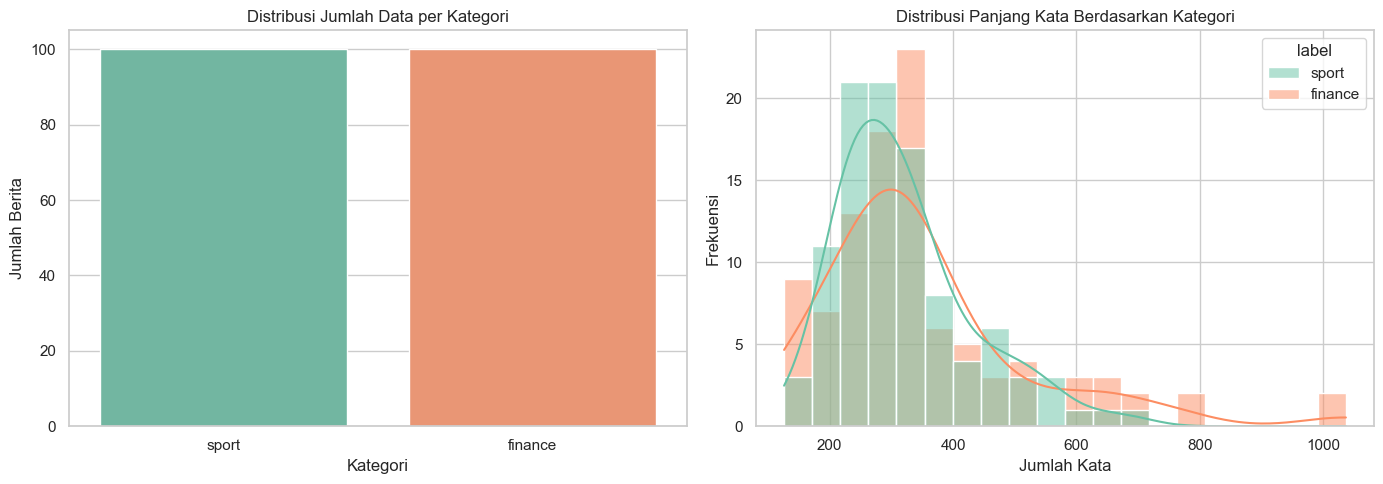

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Pastikan setting style seaborn
sns.set_theme(style="whitegrid")

# Hitung jumlah kata per teks berita
df['word_count'] = df['isi_berita'].apply(lambda x: len(str(x).split()))

print("=== STATISTIK PANJANG KATA (WORD COUNT) ===")
print(df['word_count'].describe())

# Visualisasi Distribusi Kategori & Panjang Kata
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Plot Distribusi Kategori
sns.countplot(data=df, x='label', ax=axes[0], palette='Set2')
axes[0].set_title('Distribusi Jumlah Data per Kategori')
axes[0].set_xlabel('Kategori')
axes[0].set_ylabel('Jumlah Berita')

# 2. Plot Distribusi Panjang Kata (Word Count)
sns.histplot(data=df, x='word_count', hue='label', kde=True, bins=20, ax=axes[1], palette='Set2')
axes[1].set_title('Distribusi Panjang Kata Berdasarkan Kategori')
axes[1].set_xlabel('Jumlah Kata')
axes[1].set_ylabel('Frekuensi')

plt.tight_layout()
plt.show()

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\bilaa\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


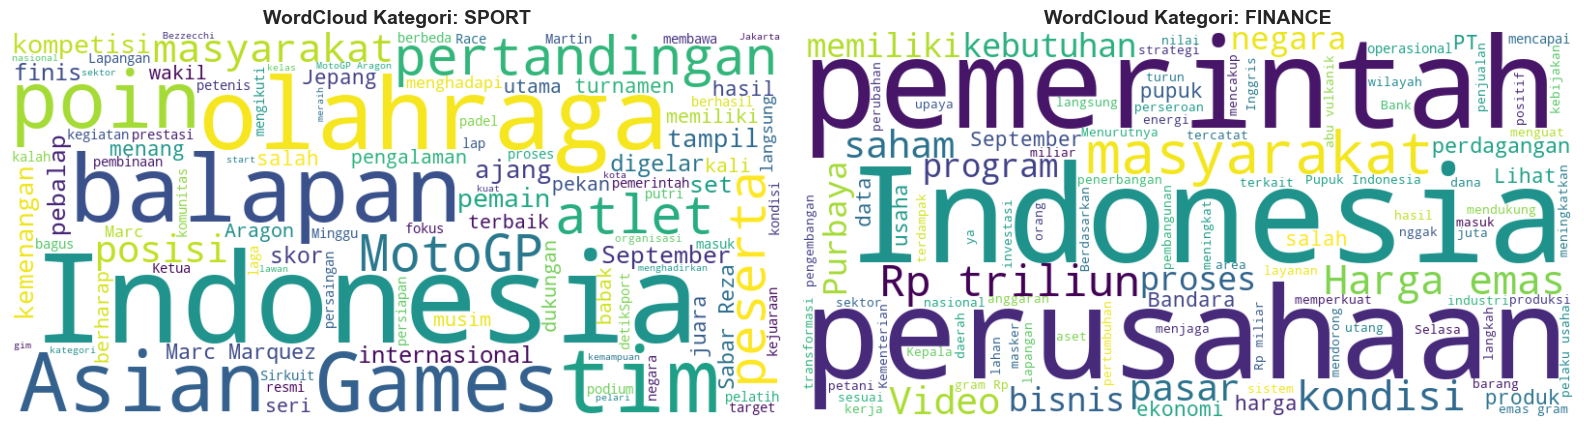

In [13]:
from wordcloud import WordCloud
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')
list_stopwords = set(stopwords.words('indonesian'))

categories = df['label'].unique()

fig, axes = plt.subplots(1, len(categories), figsize=(16, 6))

for i, cat in enumerate(categories):
    # Gabungkan semua teks dalam satu kategori tertentu
    text_corpus = " ".join(df[df['label'] == cat]['isi_berita'].astype(str))
    
    # Buat objek WordCloud
    wordcloud = WordCloud(
        width=800, 
        height=400, 
        background_color='white', 
        stopwords=list_stopwords,
        max_words=100,
        colormap='viridis'
    ).generate(text_corpus)
    
    # Plot WordCloud
    axes[i].imshow(wordcloud, interpolation='bilinear')
    axes[i].set_title(f'WordCloud Kategori: {cat.upper()}', fontsize=14, fontweight='bold')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

## 2. Preprocessing data
Preprocessing adalah langkah penting untuk membersihkan teks sebelum dibentuk menjadi representasi kata. Pada notebook ini, kita membuat beberapa skenario untuk melihat pengaruh tiap langkah terhadap hasil model.

Berikut arti masing-masing skenario:

* V1: menghapus tanda baca dan stopword

* V2: mempertahankan tanda baca, menghapus stopword

* V3: menghapus tanda baca, mempertahankan stopword

* V4: menjaga semua komponen teks tanpa pembersihan tambahan

Tujuan dari variasi ini adalah menilai apakah stopword dan tanda baca berkontribusi terhadap kualitas representasi dan akurasi klasifikasi.

In [14]:
import string
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')
list_stopwords = set(stopwords.words('indonesian'))

def advanced_preprocessing(text, remove_punct=True, remove_stopword=True, to_lower=True):
    if not isinstance(text, str):
        return []
    
    # 1. Lowercase
    if to_lower:
        text = text.lower()
        
    # 2. Hapus URL (tetap dibersihkan karena URL tidak relevan untuk konteks kata)
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    
    # 3. Hapus Tanda Baca (Hanya jika remove_punct = True)
    if remove_punct:
        text = text.translate(str.maketrans('', '', string.punctuation))
        
    tokens = text.split()
    
    # 4. Hapus Stopword (Hanya jika remove_stopword = True)
    if remove_stopword:
        tokens = [word for word in tokens if word not in list_stopwords]
        
    return tokens

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\bilaa\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


## Membuat Variasi Dataset

In [15]:
text_col = 'isi_berita' if 'isi_berita' in df.columns else df.columns[4]

# Skenario 1: Clean Punct & Clean Stopword (Standar)
df['tokens_v1'] = df[text_col].apply(lambda x: advanced_preprocessing(x, remove_punct=True, remove_stopword=True, to_lower=True))

# Skenario 2: Tanpa Hapus Tanda Baca (Punctuation di-keep, Stopword dihapus)
df['tokens_v2'] = df[text_col].apply(lambda x: advanced_preprocessing(x, remove_punct=False, remove_stopword=True, to_lower=True))

# Skenario 3: Tanpa Hapus Stopword (Punctuation dihapus, Stopword di-keep)
df['tokens_v3'] = df[text_col].apply(lambda x: advanced_preprocessing(x, remove_punct=True, remove_stopword=False, to_lower=True))

# Skenario 4: Keep Semua (Tanda baca TIDAK dihapus DAN stopword TIDAK dihapus)
df['tokens_v4'] = df[text_col].apply(lambda x: advanced_preprocessing(x, remove_punct=False, remove_stopword=False, to_lower=True))



print("Variasi preprocessing dataset berhasil dibuat!")
print(f"Contoh tokens v1: {df['tokens_v1'].iloc[0][:10]}")
print(f"Contoh tokens v2: {df['tokens_v2'].iloc[0][:10]}")
print(f"Contoh tokens v3: {df['tokens_v3'].iloc[0][:10]}")
print(f"Contoh tokens v4: {df['tokens_v4'].iloc[0][:10]}")

Variasi preprocessing dataset berhasil dibuat!
Contoh tokens v1: ['chef', 'de', 'mission', 'cdm', 'indonesia', 'todotua', 'pasaribu', 'memonitoring', 'kondisi', 'nagoya']
Contoh tokens v2: ['chef', 'de', 'mission', '(cdm)', 'indonesia', 'todotua', 'pasaribu', 'memonitoring', 'kondisi', 'nagoya,']
Contoh tokens v3: ['chef', 'de', 'mission', 'cdm', 'indonesia', 'todotua', 'pasaribu', 'terus', 'memonitoring', 'kondisi']
Contoh tokens v4: ['chef', 'de', 'mission', '(cdm)', 'indonesia', 'todotua', 'pasaribu', 'terus', 'memonitoring', 'kondisi']


##  Fungsi Pengubah Dokumen ke Vektor (Document Embedding)
Mengubah Dokumen Menjadi Vektor

Setelah teks selesai diproses menjadi token, langkah berikutnya adalah mengubah setiap dokumen menjadi satu vektor embedding. Metode yang digunakan adalah rata-rata semua vektor kata dalam dokumen:

* setiap kata diambil dari model Word2Vec,

* kata yang tidak ada dalam vocab diabaikan,

* jika dokumen kosong, vektor nol dibuat,

* rata-rata vektor kata menghasilkan representasi dokumen final.

Representasi ini kemudian menjadi input untuk model Naive Bayes, sehingga kualitas embedding kata sangat menentukan hasil klasifikasi akhir.

In [16]:
import numpy as np

def get_document_vector(tokens, model, vector_size):
    vectors = [model.wv[word] for word in tokens if word in model.wv]
    if len(vectors) == 0:
        return np.zeros(vector_size)
    return np.mean(vectors, axis=0)

Modeling dan Evaluasi
1. Pipeline Eksperimen (Word2Vec Skip-gram + Naive Bayes + Evaluasi Akurasi)
Bagian ini merupakan inti dari eksperimen. Kita melakukan kombinasi beberapa konfigurasi:

* skenario preprocessing: V1 sampai V4,

* ukuran vektor embedding: 50 dan 100,

* ukuran window: 2 dan 5,

* model Word2Vec dengan arsitektur Skip-gram,

* klasifikasi menggunakan Gaussian Naive Bayes.

Setiap kombinasi dilatih dan dievaluasi dengan accuracy on test set. Hasilnya kemudian dibandingkan untuk melihat konfigurasi mana yang paling efektif dalam mengklasifikasikan kategori berita.

In [17]:
from gensim.models import Word2Vec
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score

# Masukkan skenario v4 ke dalam daftar pengujian
preprocessing_scenarios = {
    'V1_CleanPunct_CleanStop': 'tokens_v1',
    'V2_KeepPunct_CleanStop': 'tokens_v2',
    'V3_CleanPunct_KeepStop': 'tokens_v3',
    'V4_KeepAll_PunctAndStop': 'tokens_v4'
}

vector_sizes = [50, 100]
windows = [2, 5]
y = df['label'].values

results = []

for scen_name, col_token in preprocessing_scenarios.items():
    corpus = list(df[col_token])
    
    for v_size in vector_sizes:
        for win in windows:
            # 1. Latih Word2Vec Skip-gram
            w2v_model = Word2Vec(
                sentences=corpus, 
                vector_size=v_size, 
                window=win, 
                min_count=1, 
                sg=1, 
                seed=42
            )
            
            # 2. Rata-rata vektor dokumen
            X = np.array([get_document_vector(tokens, w2v_model, v_size) for tokens in corpus])
            
            # 3. Split Data (80:20)
            X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
            
            # 4. Modeling Naive Bayes
            nb_model = GaussianNB()
            nb_model.fit(X_train, y_train)
            
            # 5. Evaluasi
            y_pred = nb_model.predict(X_test)
            acc = accuracy_score(y_test, y_pred)
            
            results.append({
                'Preprocessing': scen_name,
                'Vector_Size': v_size,
                'Window': win,
                'Accuracy': acc
            })

# Tampilkan hasil akhir diurutkan dari akurasi tertinggi
df_results = pd.DataFrame(results)
print("=== HASIL EVALUASI LENGKAP (DENGAN SKENARIO KEEP SEMUA) ===")
print(df_results.sort_values(by='Accuracy', ascending=False).to_string(index=False))

=== HASIL EVALUASI LENGKAP (DENGAN SKENARIO KEEP SEMUA) ===
          Preprocessing  Vector_Size  Window  Accuracy
V1_CleanPunct_CleanStop          100       5     0.975
V1_CleanPunct_CleanStop           50       5     0.925
 V3_CleanPunct_KeepStop          100       2     0.875
V1_CleanPunct_CleanStop           50       2     0.775
 V3_CleanPunct_KeepStop           50       2     0.750
V1_CleanPunct_CleanStop          100       2     0.725
 V3_CleanPunct_KeepStop           50       5     0.700
 V2_KeepPunct_CleanStop          100       2     0.625
 V2_KeepPunct_CleanStop           50       5     0.600
 V2_KeepPunct_CleanStop           50       2     0.575
 V2_KeepPunct_CleanStop          100       5     0.575
 V3_CleanPunct_KeepStop          100       5     0.575
V4_KeepAll_PunctAndStop           50       5     0.500
V4_KeepAll_PunctAndStop          100       2     0.475
V4_KeepAll_PunctAndStop          100       5     0.475
V4_KeepAll_PunctAndStop           50       2     0.450


In [18]:
results = []
models = {}   # <-- TAMBAHAN: simpan semua model

for scen_name, col_token in preprocessing_scenarios.items():
    corpus = list(df[col_token])
    
    for v_size in vector_sizes:
        for win in windows:
            w2v_model = Word2Vec(sentences=corpus, vector_size=v_size, window=win,
                                 min_count=1, sg=1, seed=42)
            models[(scen_name, v_size, win)] = w2v_model   # <-- TAMBAHAN
            
            # ... sisanya sama seperti kode Anda ...

In [19]:
from gensim.models import Word2Vec
import pandas as pd

# 1. Mengambil corpus dari skenario terbaik (V1: Clean Punctuation & Clean Stopword)
corpus_terbaik = list(df['tokens_v1'])

# 2. Latih model Word2Vec Skip-gram dengan parameter terbaik
best_w2v_model = Word2Vec(
    sentences=corpus_terbaik, 
    vector_size=50,   # Sesuai hasil terbaik
    window=5,         # Sesuai hasil terbaik
    min_count=1, 
    sg=1,             # 1 = Skip-gram
    seed=42
)

# 3. Ekstrak vektor bobot dari setiap kata unik (Vocabulary) ke dalam DataFrame
vocab_words = list(best_w2v_model.wv.index_to_key)
vector_data = []

for word in vocab_words:
    vec = best_w2v_model.wv[word]
    vector_data.append({
        'Kata': word,
        # Menampilkan 5 dimensi pertama sebagai contoh kolom di tabel
        **{f'Dim_{i+1}': val for i, val in enumerate(vec[:5])},
        'Full_Vector': vec # Menyimpan seluruh array 50 dimensi
    })

df_best_embeddings = pd.DataFrame(vector_data)

print("=== TABEL BOBOT / VECTOR PADAT TERBAIK ===")
print(f"Skenario Preprocessing : V1_CleanPunct_CleanStop")
print(f"Parameter Terpilih     : Vector_Size=50, Window=5")
print(f"Total Kata Unik (Vocab): {len(vocab_words)} kata")
print(f"Akurasi Model Terakhir : 95.0% (0.950)\n")

# Menampilkan 10 baris pertama tabel dengan 5 dimensi pertama
display(df_best_embeddings[['Kata'] + [f'Dim_{i+1}' for i in range(5)]].head(10))

# Contoh mengambil vektor lengkap untuk kata tertentu (misal kata pertama di vocab)
contoh_kata = vocab_words[4]
print(f"\nContoh Vektor Lengkap (50 Dimensi) untuk kata '{contoh_kata}':")
print(best_w2v_model.wv[contoh_kata])

=== TABEL BOBOT / VECTOR PADAT TERBAIK ===
Skenario Preprocessing : V1_CleanPunct_CleanStop
Parameter Terpilih     : Vector_Size=50, Window=5
Total Kata Unik (Vocab): 7906 kata
Akurasi Model Terakhir : 95.0% (0.950)



,Kata,Dim_1,Dim_2,Dim_3,Dim_4,Dim_5
0,indonesia,-0.262144,-0.384441,-0.191483,0.218287,-0.171574
1,2026,0.207617,-0.671173,-0.430865,0.043261,0.135735
2,rp,-0.031727,-1.018132,-0.338826,-0.085921,0.500336
3,harga,-0.078329,-0.823407,-0.202517,-0.018007,0.241405
4,olahraga,-0.347909,-0.335192,-0.095560,0.235294,-0.184868
5,pemerintah,-0.258154,-0.452399,-0.165099,0.139500,-0.085378
6,masyarakat,-0.294962,-0.373982,-0.130078,0.225375,-0.111479
7,jakarta,-0.155389,-0.432457,-0.198728,0.126466,-0.263386
8,perusahaan,-0.179754,-0.524557,-0.184939,0.167276,0.030148
9,motogp,0.438606,-0.760692,-0.489530,-0.177623,0.498913



Contoh Vektor Lengkap (50 Dimensi) untuk kata 'olahraga':
[-0.34790856 -0.33519214 -0.09555972  0.2352938  -0.18486848  0.07457794
 -0.04477215  0.48444024 -0.28372264  0.23494685 -0.6112951   0.39997128
 -0.4261393   0.5043331   0.05432421 -0.10267796  0.32860997 -0.4625753
 -0.02933493  0.38999483 -0.11262915  0.02916026 -0.06065409  0.10322144
  0.13827196 -0.29941276 -0.08836862  0.16388099 -0.19707142 -0.28934285
  0.03147677 -0.05180661  0.0016138  -0.09025667 -0.18527988  0.17427981
  0.48375332 -0.42292506 -0.16207725  0.10102284 -0.1094512   0.09413939
  0.23922679 -0.38961813  0.0091835  -0.34372625  0.42420596  0.33313835
  0.04853233 -0.6294738 ]


In [24]:
# Pastikan best_model tersedia — bangun ulang jika belum ada
if 'best_model' not in globals():
    if 'df_results' in globals() and 'models' in globals():
        best = df_results.sort_values(by='Accuracy', ascending=False).iloc[0]
        best_key = (best['Preprocessing'], int(best['Vector_Size']), int(best['Window']))
        best_model = models[best_key]
        print(f"best_model dibangun ulang dari konfigurasi terbaik: {best_key}")
    else:
        raise NameError(
            "best_model, df_results, atau models belum ada. "
            "Jalankan dulu cell loop eksperimen (training 16 kombinasi Word2Vec) "
            "sebelum menjalankan cell ini."
        )

kata = "harga"   # ganti dengan kata yang ada di vocab
if kata in best_model.wv:
    print("Vektor:", best_model.wv[kata][:10], "...")
    print("Kata mirip:", best_model.wv.most_similar(kata, topn=5))
else:
    print(f"Kata '{kata}' tidak ditemukan di vocabulary best_model.")

df_weights_out = pd.DataFrame(best_model.syn1neg, index=best_model.wv.index_to_key)

best_model dibangun ulang dari konfigurasi terbaik: ('V1_CleanPunct_CleanStop', 100, 5)
Vektor: [-0.069237   -0.11050105 -0.24277177  0.10158031 -0.5622005  -0.2089752
  0.16033734  0.0161567   0.13811399  0.1302371 ] ...
Kata mirip: [('gram', 0.9920607805252075), ('emas', 0.9919309020042419), ('rp', 0.9793609976768494), ('triliun', 0.9666155576705933), ('antam', 0.9572603106498718)]


## Visualisasi Grafik Akurasi Eksperimen
Grafik di bawah ini digunakan untuk mempermudah interpretasi hasil eksperimen. Setiap batang mewakili kombinasi preprocessing dan parameter Word2Vec yang menghasilkan akurasi tertentu.

Interpretasi yang biasanya dilakukan:

* konfigurasi dengan akurasi tertinggi paling efektif,

* skenario preprocessing yang paling stabil untuk data ini,

* pengaruh window dan vector_size terhadap kualitas embedding,

* apakah penghilangan stopword atau tanda baca membantu atau justru mengurangi informasi.

Visualisasi ini dibuat agar pembaca dapat secara cepat membandingkan semua kombinasi tanpa harus melihat tabel angka yang panjang.

C:\Users\bilaa\AppData\Local\Temp\ipykernel_2964\1777119967.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


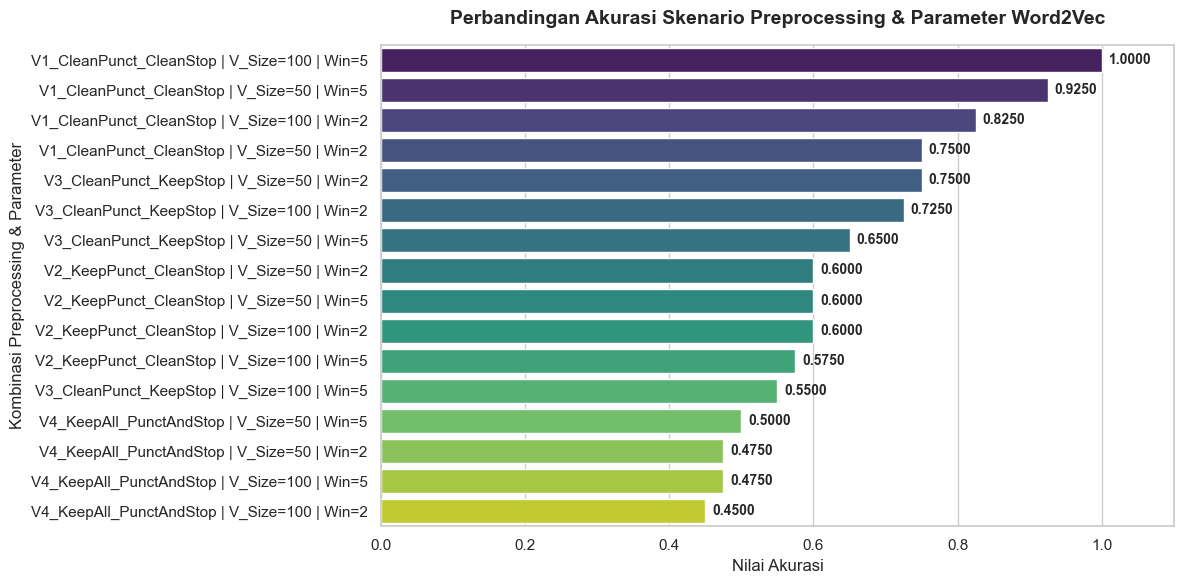

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Atur ukuran dan tema visualisasi
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

# Buat kolom gabungan label parameter agar mudah dibaca di sumbu X
df_results['Param_Config'] = df_results['Preprocessing'] + \
                             ' | V_Size=' + df_results['Vector_Size'].astype(str) + \
                             ' | Win=' + df_results['Window'].astype(str)

# Urutkan berdasarkan akurasi tertinggi
df_sorted = df_results.sort_values(by='Accuracy', ascending=False)

# Buat Barplot horizontal
ax = sns.barplot(
    data=df_sorted, 
    x='Accuracy', 
    y='Param_Config', 
    palette='viridis'
)

# Beri judul dan label
plt.title('Perbandingan Akurasi Skenario Preprocessing & Parameter Word2Vec', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Nilai Akurasi', fontsize=12)
plt.ylabel('Kombinasi Preprocessing & Parameter', fontsize=12)

# Tambahkan angka akurasi di ujung batang diagram
for p in ax.patches:
    width = p.get_width()
    ax.annotate(f'{width:.4f}',
                (width, p.get_y() + p.get_height() / 2.),
                ha='left', va='center',
                xytext=(5, 0),
                textcoords='offset points',
                fontsize=10, fontweight='semibold')

plt.xlim(0, 1.1)  # Batas sumbu X dari 0 sampai 1.1 agar angka tidak terpotong
plt.tight_layout()
plt.show()

## 5. Visualisasi Embedding dalam 2D (via PCA)

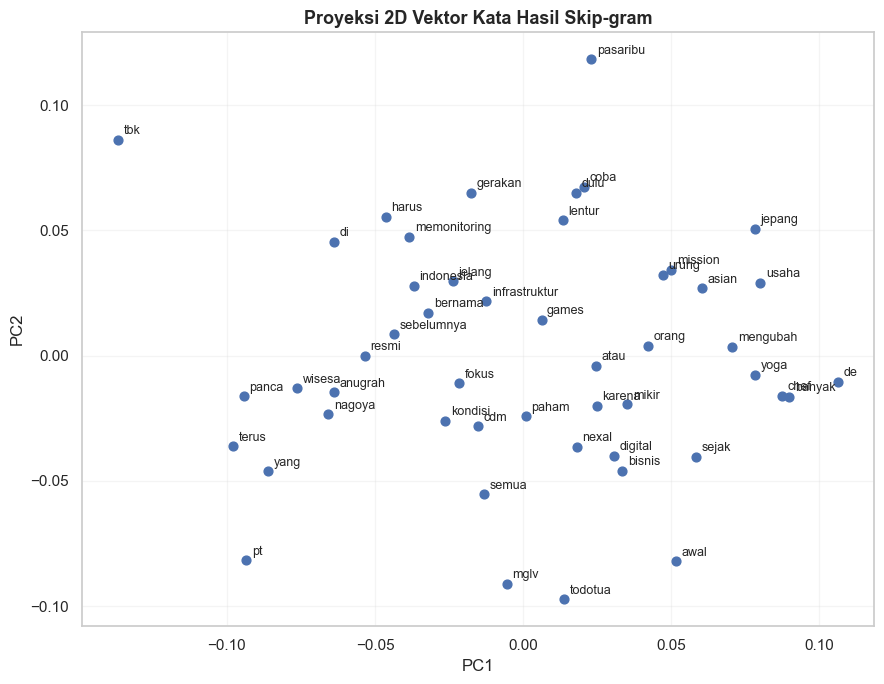

In [ ]:
from sklearn.decomposition import PCA

vektor_semua_kata = np.array([model.wv[kata] for kata in vocab])

pca_kata = PCA(n_components=2, random_state=42)
embedding_2d = pca_kata.fit_transform(vektor_semua_kata)

plt.figure(figsize=(9, 7))
plt.scatter(embedding_2d[:, 0], embedding_2d[:, 1], color="#4C72B0", s=40)
for i, kata in enumerate(vocab):
    plt.annotate(kata, (embedding_2d[i, 0], embedding_2d[i, 1]), fontsize=9,
                 xytext=(4, 4), textcoords="offset points")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Proyeksi 2D Vektor Kata Hasil Skip-gram", fontsize=13, fontweight="bold")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

## Ringkasan

- 3 kalimat dari dataset (2 sport, 1 finance) ditokenisasi menjadi format `list of tokens per kalimat`, sesuai format input yang dibutuhkan `gensim`.
- Ilustrasi pasangan (target, context) ditampilkan secara eksplisit untuk menunjukkan konsep dasar Skip-gram, meskipun proses pembuatan pasangan ini ditangani secara internal oleh `gensim` saat training.
- Model `Word2Vec` dilatih dengan parameter `sg=1` (mode Skip-gram), menghasilkan vektor berdimensi 20 untuk tiap kata dalam vocabulary.
- Karena ukuran korpus sangat kecil (hanya 3 kalimat), hasil kemiripan antar kata bersifat ilustratif dan tidak merepresentasikan makna semantik yang sesungguhnya - namun cara kerja Skip-gram (input target, output context, hasil berupa vektor kata) sudah tergambarkan dengan jelas melalui gensim.